# Survey Data Exploration, Cleaning, and Insights

This notebook explores the survey dataset, cleans key fields, and produces quick insights for analysis and dashboards.

## Goals
1. Understand the dataset shape, types, and missingness.
2. Standardize columns and convert numeric fields.
3. Summarize top skills and trends with simple plots.

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

In [84]:
data_path = "survey_data_updated.csv"
df_raw = pd.read_csv(data_path, low_memory=False)

print("rows:", len(df_raw), "cols:", df_raw.shape[1])
df_raw.head()

rows: 18845 cols: 114


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,...,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,...,Agree,Agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,37,27,Developer Experience,NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,C#,C#,C#,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
2,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,Traditional public search engine;AI-powered se...,15,11,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,Serbia,NaN,NaN,HTML/CSS;JavaScript;TypeScript,HTML/CSS;JavaScript;TypeScript,HTML/CSS;JavaScript;TypeScript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,11,"I used to be a developer by profession, but no...",35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,20,NaN,Project manager,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,JavaScript;Python;Ruby,C#;Crystal;Java;JavaScript;Python;Ruby,JavaScript;Python;Ruby,...,Neither agree nor disagree,Neither agree nor disagree,3-5 times a week,6-10 times a week,6-10 times a week,30-60 minutes a day,60-120 minutes a day,Amount of technical debt;Number of software to...,DevOps function;Automated testing;Observabilit...,Cloud only (single or multi-cloud),Internal Developer portal,Healthcare,50.0,0.0,0.0,25.0,10.0,0.0,15.0,0.0,0.0,Appropriate in length,Easy,NaN,8.0
4,12,I am a developer by profession,45-54 years old,"Employed, full-time",In-person,Apples,Hobby;School or academic work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,30,25,Developer Advocate,NaN,NaN,NaN,NaN,NaN,Poland,NaN,NaN,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Power...,C#;HTML/CSS;JavaScript;PowerShell;Rust;SQL;Typ...,C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither 

## Data Overview

Check schema, data types, and missing values to guide cleaning.

In [63]:
df_raw.info()

missing_pct = (df_raw.isna().mean() * 100).round(1).sort_values(ascending=False)
missing_pct.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18845 entries, 0 to 18844
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 16.4+ MB


AINextMuch less integrated       98.1
AINextLess integrated            96.0
AINextNo change                  76.8
AINextMuch more integrated       72.6
EmbeddedAdmired                  69.3
EmbeddedWantToWorkWith           68.6
EmbeddedHaveWorkedWith           63.4
AIToolNot interested in Using    53.4
AINextMore integrated            52.1
ConvertedCompYearly              49.3
AIToolInterested in Using        40.6
Knowledge_9                      38.7
Frequency_3                      38.5
Knowledge_7                      38.5
Knowledge_8                      38.5
Knowledge_5                      38.2
Knowledge_6                      38.2
Knowledge_4                      38.0
ProfessionalTech                 38.0
Knowledge_2                      38.0
dtype: float64

## Cleaning and Standardization

This section creates a cleaned copy with standardized column names, numeric conversions, and a numeric age midpoint.

In [64]:
df = df_raw.copy()

df.columns = (
    df.columns.str.strip()
    .str.replace(" ", "_", regex=False)
    .str.replace("__", "_", regex=False)
)

numeric_cols = ["YearsCode", "YearsCodePro", "WorkExp", "CompTotal", "ConvertedCompYearly"]
special_map = {"Less than 1 year": "0", "More than 50 years": "50"}

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].replace(special_map)
        df[col] = pd.to_numeric(df[col], errors="coerce")

def parse_age(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if "-" in text:
        parts = text.split("-")
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    if text.lower().startswith("under"):
        return np.nan
    if "years or older" in text or "65+" in text:
        return 65.0
    try:
        return float(text)
    except ValueError:
        return np.nan

if "Age" in df.columns:
    df["Age_Midpoint"] = df["Age"].apply(parse_age)

df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,...,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat,Age_Midpoint
0,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20.0,17.0,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,...,Agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN
1,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,37.0,27.0,Developer Experience,NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,C#,C#,C#,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN,NaN
2,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,Traditional public search engine;AI-powered se...,15.0,11.0,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,Serbia,NaN,NaN,HTML/CSS;JavaScript;TypeScript,HTML/CSS;JavaScript;TypeScript,HTML/CSS;JavaScript;TypeScript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN,NaN
3,11,"I used to be a developer by profession, but no...",35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,20.0,NaN,Project manager,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,JavaScript;Python;Ruby,C#;Crystal;Java;JavaScript;Python;Ruby,JavaScript;Python;Ruby,...,Neither agree nor disagree,3-5 times a week,6-10 times a week,6-10 times a week,30-60 minutes a day,60-120 minutes a day,Amount of technical debt;Number of software to...,DevOps function;Automated testing;Observabilit...,Cloud only (single or multi-cloud),Internal Developer portal,Healthcare,50.0,0.0,0.0,25.0,10.0,0.0,15.0,0.0,0.0,Appropriate in length,Easy,NaN,8.0,NaN
4,12,I am a developer by profession,45-54 years old,"Employed, full-time",In-person,Apples,Hobby;School or academic work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Books / Physical media;School (i.e., Universit...",NaN,NaN,30.0,25.0,Developer Advocate,NaN,NaN,NaN,NaN,NaN,Poland,NaN,NaN,C;C#;C++;Delphi;HTML/CSS;Java;JavaScript;Power...,C#;HTML/CSS;JavaScript;PowerShell;Rust;SQL;Typ...,C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScript,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor d

## Multi-Select Helper

Many fields are semicolon-delimited lists (for example, languages and databases). The helpers below make it easy to summarize them.

In [65]:
def explode_multiselect(dataframe, column):
    series = (
        dataframe[column]
        .dropna()
        .astype(str)
        .str.split(";")
        .explode()
        .str.strip()
    )
    return series[series != ""]

def top_counts(dataframe, column, n=10):
    series = explode_multiselect(dataframe, column)
    return series.value_counts().head(n)

object_cols = df.select_dtypes(include="object").columns
multi_select_cols = []

for col in object_cols:
    sample = df[col].dropna().astype(str).head(1000)
    if sample.str.contains(";").any():
        multi_select_cols.append(col)

multi_select_cols[:10]

['Employment',
 'CodingActivities',
 'LearnCode',
 'LearnCodeOnline',
 'TechDoc',
 'BuyNewTool',
 'TechEndorse',
 'LanguageHaveWorkedWith',
 'LanguageWantToWorkWith',
 'LanguageAdmired']

## Quick Insights

These summaries highlight the most common skills and trends in the dataset.

In [66]:
top_languages = top_counts(df, "LanguageHaveWorkedWith", 10)
top_databases = top_counts(df, "DatabaseHaveWorkedWith", 10)
top_platforms = top_counts(df, "PlatformHaveWorkedWith", 10)
top_webframes = top_counts(df, "WebframeHaveWorkedWith", 10)
top_devtypes = top_counts(df, "DevType", 10)

print("Top Languages:\n", top_languages)
print("\nTop Databases:\n", top_databases)
print("\nTop Platforms:\n", top_platforms)
print("\nTop Web Frameworks:\n", top_webframes)
print("\nTop Developer Types:\n", top_devtypes)

Top Languages:
 LanguageHaveWorkedWith
JavaScript                 14943
SQL                        12602
HTML/CSS                   12410
TypeScript                 10709
Python                      9590
Bash/Shell (all shells)     7244
C#                          6340
Java                        5982
PHP                         4644
PowerShell                  3438
Name: count, dtype: int64

Top Databases:
 DatabaseHaveWorkedWith
PostgreSQL              11514
MySQL                    8556
SQLite                   7021
MongoDB                  5930
Microsoft SQL Server     5870
Redis                    5814
MariaDB                  3994
Elasticsearch            3491
Dynamodb                 2268
Oracle                   1907
Name: count, dtype: int64

Top Platforms:
 PlatformHaveWorkedWith
Amazon Web Services (AWS)    10871
Microsoft Azure               6681
Google Cloud                  5537
Cloudflare                    3874
Digital Ocean                 3170
Firebase                

### Visualization: Top 10 Skills and Tools

Notes:
- Counts come from multi-select fields, so one response can add multiple mentions.
- High counts often mirror survey composition rather than true market share.
- The long tail can still be important for niche roles or regions.

Suggestions:
- Compare "Have Worked With" vs "Want To Work With" to surface demand gaps.
- Segment by country, experience, or role to find meaningful shifts.
- Use these as default dashboard filters and drill into outliers.

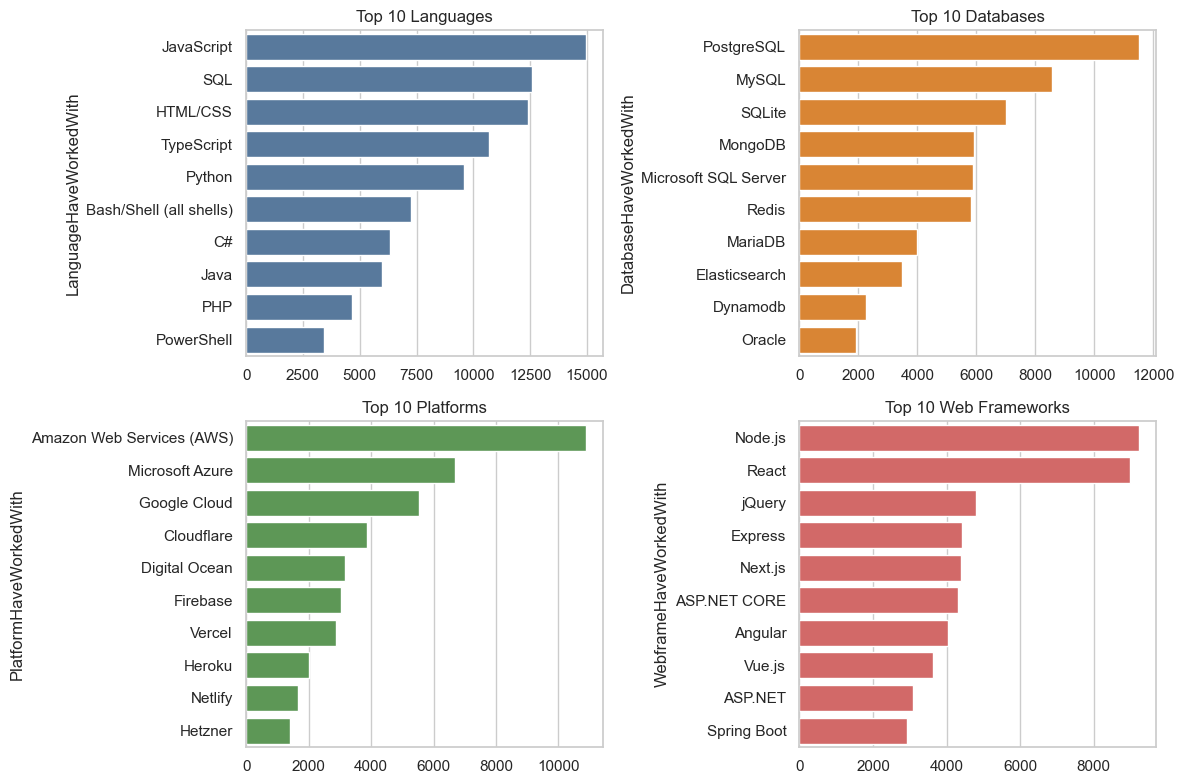

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.barplot(x=top_languages.values, y=top_languages.index, ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Top 10 Languages")

sns.barplot(x=top_databases.values, y=top_databases.index, ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Top 10 Databases")

sns.barplot(x=top_platforms.values, y=top_platforms.index, ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Top 10 Platforms")

sns.barplot(x=top_webframes.values, y=top_webframes.index, ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Top 10 Web Frameworks")

plt.tight_layout()
plt.savefig("images/01_top_skills_tools.png", dpi=300, bbox_inches="tight")
plt.show()

### Visualization: Age Distribution

Notes:
- Ages are midpoint values from ranges, so the distribution is approximate.
- Non-range responses are excluded, which can reduce sample size.
- The shape may reflect survey reach more than the overall developer population.

Suggestions:
- Segment by YearsCodePro or role to see age and experience alignment.
- Consider broader age cohorts to stabilize comparisons.

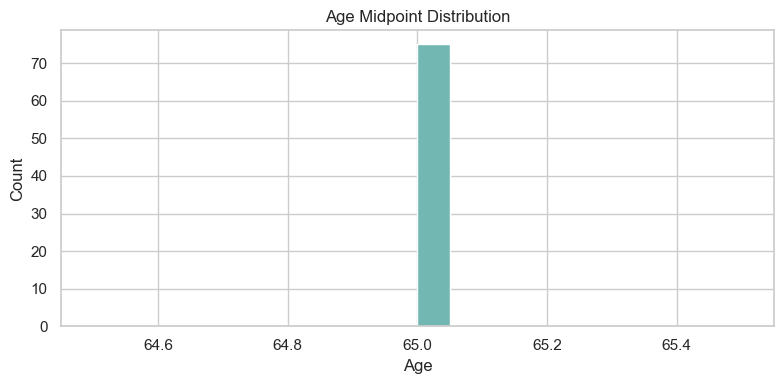

In [ ]:
if "Age_Midpoint" in df.columns:
    plt.figure(figsize=(8, 4))
    df["Age_Midpoint"].dropna().plot(kind="hist", bins=20, color="#72B7B2")
    plt.title("Age Midpoint Distribution")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig("images/02_age_distribution.png", dpi=300, bbox_inches="tight")
    plt.show()

In [69]:
if "Country" in df.columns:
    country_counts = df["Country"].value_counts().head(15)
    print("Top Countries:\n", country_counts)

if "RemoteWork" in df.columns:
    remote_share = (df["RemoteWork"].value_counts(normalize=True) * 100).round(1)
    print("\nRemote Work Split (percent):\n", remote_share)

Top Countries:
 Country
United States of America                                3441
Germany                                                 1339
India                                                   1316
United Kingdom of Great Britain and Northern Ireland    1053
Ukraine                                                  931
Canada                                                   661
France                                                   598
Brazil                                                   587
Poland                                                   494
Netherlands                                              480
Italy                                                    452
Australia                                                444
Spain                                                    409
Sweden                                                   298
Austria                                                  288
Name: count, dtype: int64

Remote Work Split (percent):
 Remo

## Additional Visualizations

Use these to dig into compensation, experience, and geographic patterns.

### Visualization: Top Countries and Job Satisfaction

Notes:
- Country counts show response concentration, not population share.
- Job satisfaction depends on role, compensation, and regional context.

Suggestions:
- Normalize by population or tech workforce when possible.
- Compare job satisfaction by remote status or compensation band.

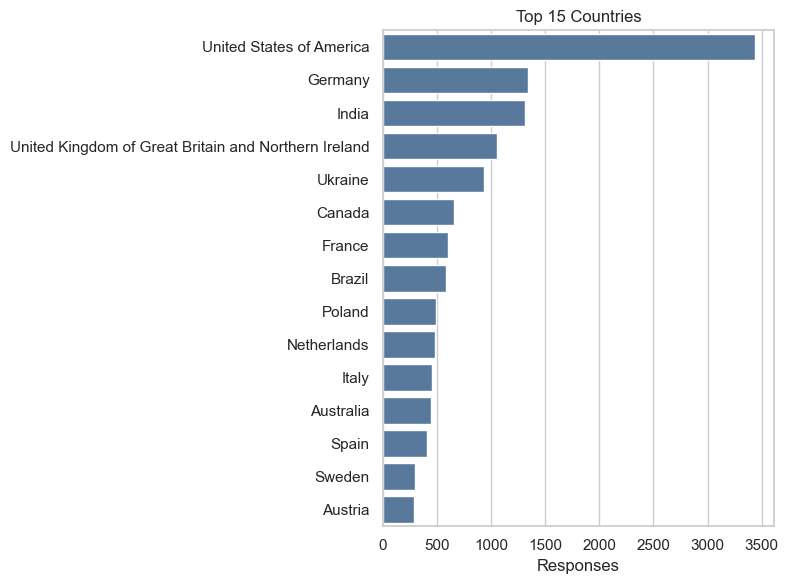

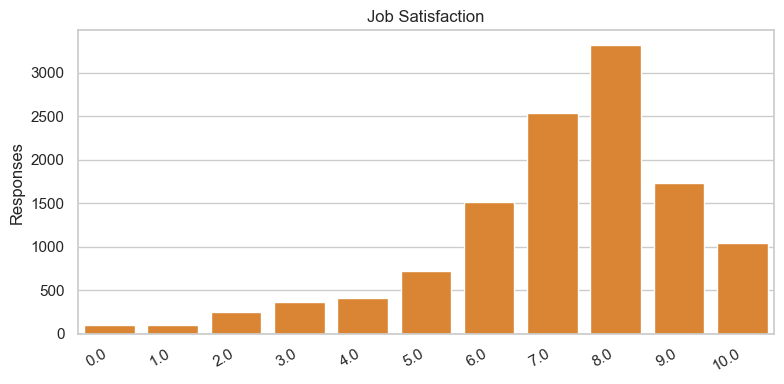

In [ ]:
if "Country" in df.columns:
    top_countries = df["Country"].value_counts().head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_countries.values, y=top_countries.index, color="#4C78A8")
    plt.title("Top 15 Countries")
    plt.xlabel("Responses")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("images/03_top_countries.png", dpi=300, bbox_inches="tight")
    plt.show()

if "JobSat" in df.columns:
    job_sat = df["JobSat"].value_counts()
    plt.figure(figsize=(8, 4))
    sns.barplot(x=job_sat.index, y=job_sat.values, color="#F58518")
    plt.title("Job Satisfaction")
    plt.xlabel("")
    plt.ylabel("Responses")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("images/04_job_satisfaction.png", dpi=300, bbox_inches="tight")
    plt.show()

### Visualization: Compensation Distribution and Remote Work

Notes:
- Compensation is right-skewed; trimming helps reveal typical ranges.
- Remote work categories are self-reported and may vary by region.

Suggestions:
- Use a log scale to compare spread across categories.
- Break down by country or role to control for mix effects.

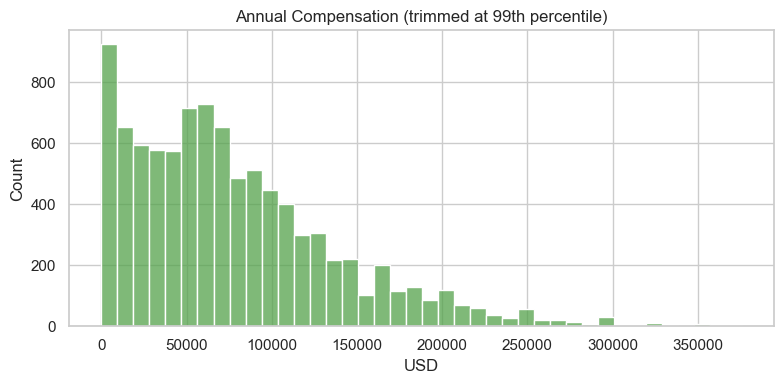

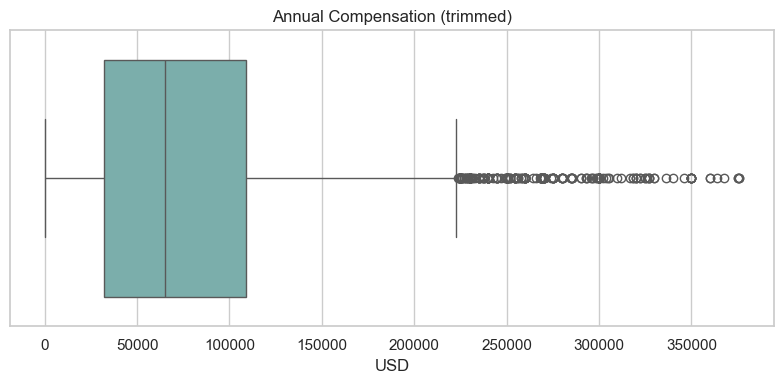

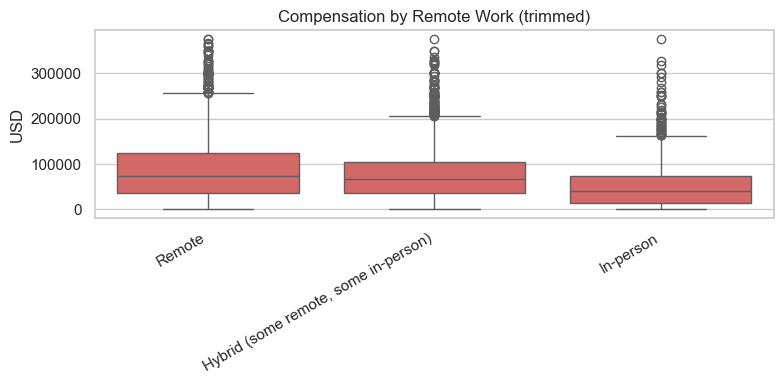

In [ ]:
if "ConvertedCompYearly" in df.columns:
    comp = df["ConvertedCompYearly"].dropna()
    comp = comp[comp > 0]
    if len(comp) > 0:
        upper = comp.quantile(0.99)
        comp_trim = comp[comp <= upper]
        plt.figure(figsize=(8, 4))
        sns.histplot(comp_trim, bins=40, color="#54A24B")
        plt.title("Annual Compensation (trimmed at 99th percentile)")
        plt.xlabel("USD")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig("images/05_compensation_distribution.png", dpi=300, bbox_inches="tight")
        plt.show()

        plt.figure(figsize=(8, 4))
        sns.boxplot(x=comp_trim, color="#72B7B2")
        plt.title("Annual Compensation (trimmed)")
        plt.xlabel("USD")
        plt.tight_layout()
        plt.savefig("images/06_compensation_boxplot.png", dpi=300, bbox_inches="tight")
        plt.show()

if "ConvertedCompYearly" in df.columns and "RemoteWork" in df.columns:
    df_comp = df[["ConvertedCompYearly", "RemoteWork"]].dropna()
    df_comp = df_comp[df_comp["ConvertedCompYearly"] > 0]
    if not df_comp.empty:
        upper = df_comp["ConvertedCompYearly"].quantile(0.99)
        df_comp = df_comp[df_comp["ConvertedCompYearly"] <= upper]
        order = df_comp["RemoteWork"].value_counts().index
        plt.figure(figsize=(8, 4))
        sns.boxplot(data=df_comp, x="RemoteWork", y="ConvertedCompYearly", order=order, color="#E45756")
        plt.title("Compensation by Remote Work (trimmed)")
        plt.xlabel("")
        plt.ylabel("USD")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig("images/07_compensation_by_remote.png", dpi=300, bbox_inches="tight")
        plt.show()

### Visualization: Experience vs Compensation and Correlations

Notes:
- The relationship is usually positive but noisy, with wide variance.
- Correlations summarize linear relationships only and are sensitive to outliers.

Suggestions:
- Add a trend line or median band by experience buckets.
- Treat correlations as directional signals, not causal claims.

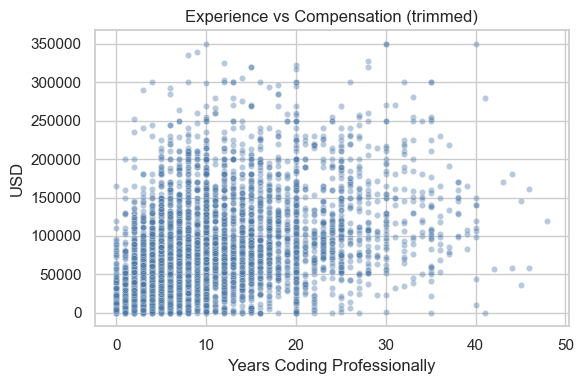

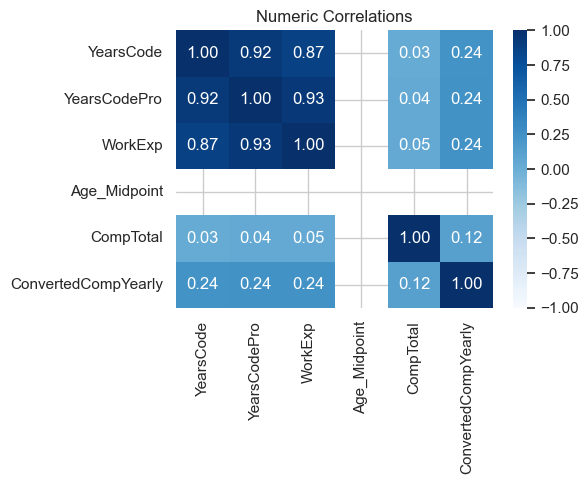

In [ ]:
if "YearsCodePro" in df.columns and "ConvertedCompYearly" in df.columns:
    sample = df[["YearsCodePro", "ConvertedCompYearly"]].dropna()
    sample = sample[(sample["YearsCodePro"] >= 0) & (sample["ConvertedCompYearly"] > 0)]
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    if not sample.empty:
        upper = sample["ConvertedCompYearly"].quantile(0.99)
        sample = sample[sample["ConvertedCompYearly"] <= upper]
        plt.figure(figsize=(6, 4))
        sns.scatterplot(data=sample, x="YearsCodePro", y="ConvertedCompYearly", alpha=0.4, s=20, color="#4C78A8")
        plt.title("Experience vs Compensation (trimmed)")
        plt.xlabel("Years Coding Professionally")
        plt.ylabel("USD")
        plt.tight_layout()
        plt.savefig("images/08_experience_vs_compensation.png", dpi=300, bbox_inches="tight")
        plt.show()

corr_cols = ["YearsCode", "YearsCodePro", "WorkExp", "Age_Midpoint", "CompTotal", "ConvertedCompYearly"]
available = [col for col in corr_cols if col in df.columns]
if len(available) >= 2:
    corr = df[available].corr(numeric_only=True)
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1)
    plt.title("Numeric Correlations")
    plt.tight_layout()
    plt.savefig("images/09_correlations_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

## Further Exploration

These views deepen the analysis by focusing on cross-sections and adoption gaps.

### Visualization: Remote Work Mix by Top Countries

Notes:
- Each bar sums to 100 percent, showing within-country remote mix.
- Only the top countries by response count are included.

Suggestions:
- Set a minimum sample size to avoid unstable percentages.
- Compare the remote mix with compensation or job satisfaction.

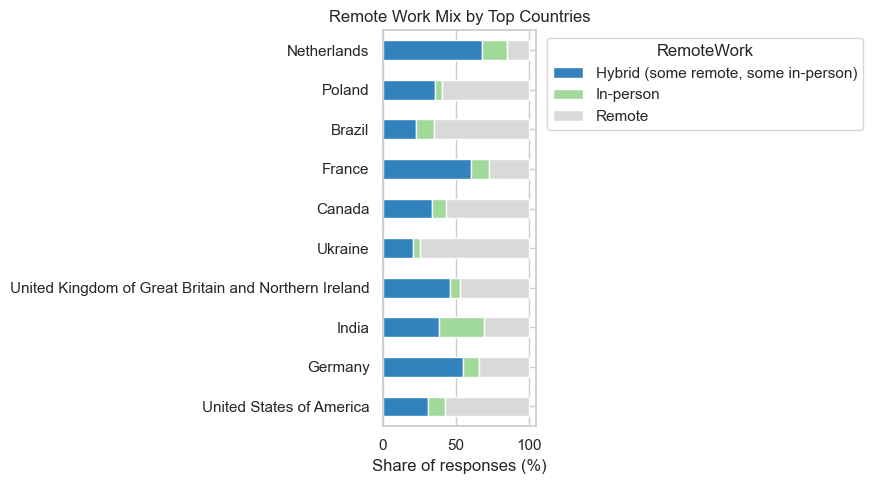

In [ ]:
if "Country" in df.columns and "RemoteWork" in df.columns:
    top_countries = df["Country"].value_counts().head(10).index
    subset = df[df["Country"].isin(top_countries)]
    mix = pd.crosstab(subset["Country"], subset["RemoteWork"], normalize="index") * 100
    mix = mix.loc[top_countries]
    mix.plot(kind="barh", stacked=True, figsize=(9, 5), colormap="tab20c")
    plt.title("Remote Work Mix by Top Countries")
    plt.xlabel("Share of responses (%)")
    plt.ylabel("")
    plt.legend(title="RemoteWork", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig("images/10_remote_work_by_country.png", dpi=300, bbox_inches="tight")
    plt.show()

### Visualization: Education vs Compensation

Notes:
- Education categories are self-reported and can be uneven in size.
- Compensation is trimmed to reduce the influence of extreme outliers.

Suggestions:
- Compare education results with YearsCodePro to add experience context.
- Consider grouping similar degrees for clearer readability.

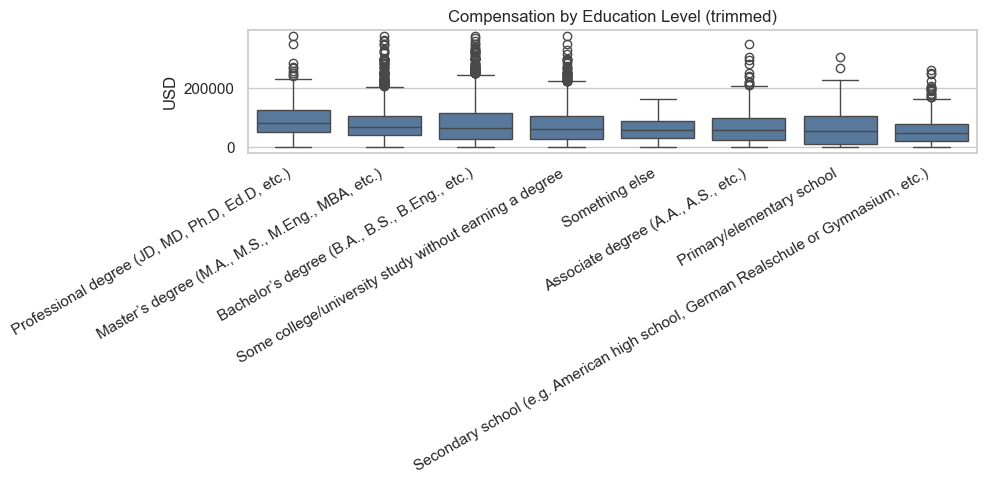

In [ ]:
if "EdLevel" in df.columns and "ConvertedCompYearly" in df.columns:
    ed_comp = df[["EdLevel", "ConvertedCompYearly"]].dropna()
    ed_comp = ed_comp[ed_comp["ConvertedCompYearly"] > 0]
    if not ed_comp.empty:
        upper = ed_comp["ConvertedCompYearly"].quantile(0.99)
        ed_comp = ed_comp[ed_comp["ConvertedCompYearly"] <= upper]
        order = ed_comp.groupby("EdLevel")["ConvertedCompYearly"].median().sort_values(ascending=False).index
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=ed_comp, x="EdLevel", y="ConvertedCompYearly", order=order, color="#4C78A8")
        plt.title("Compensation by Education Level (trimmed)")
        plt.xlabel("")
        plt.ylabel("USD")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig("images/11_compensation_by_education.png", dpi=300, bbox_inches="tight")
        plt.show()

### Visualization: AI Tool Adoption

Notes:
- Counts are multi-select mentions, so totals can exceed respondents.
- A tool can appear in both current and interested lists.

Suggestions:
- Compute an interest gap (interested minus current) to spot growth areas.
- Focus on tools with high interest but low current use.

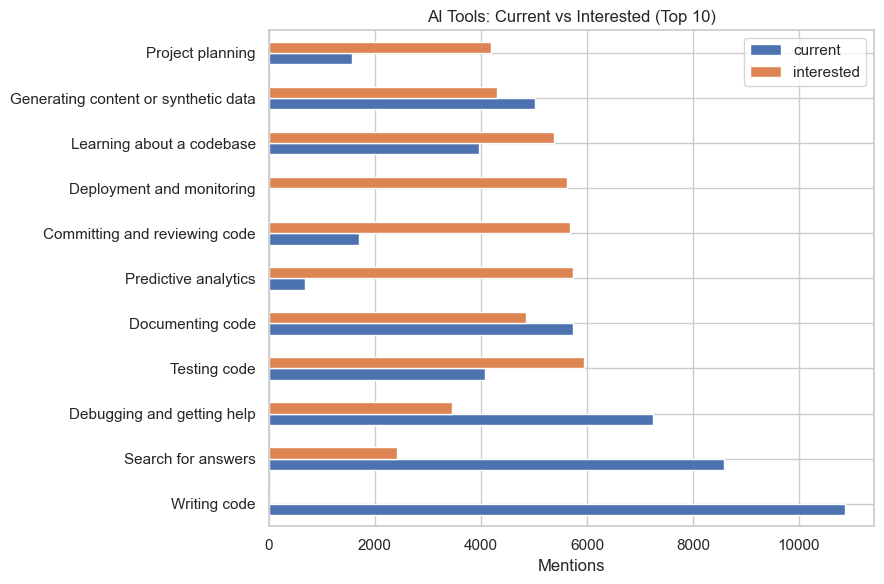

In [ ]:
if "AIToolCurrently_Using" in df.columns and "AIToolInterested_in_Using" in df.columns:
    ai_current = top_counts(df, "AIToolCurrently_Using", 10)
    ai_interested = top_counts(df, "AIToolInterested_in_Using", 10)
    ai_df = pd.concat([ai_current, ai_interested], axis=1)
    ai_df.columns = ["current", "interested"]
    ai_df = ai_df.fillna(0).astype(int)
    ai_df["max"] = ai_df.max(axis=1)
    ai_df = ai_df.sort_values("max", ascending=False).drop(columns="max")
    ai_df.plot(kind="barh", figsize=(9, 6))
    plt.title("AI Tools: Current vs Interested (Top 10)")
    plt.xlabel("Mentions")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("images/12_ai_tools_adoption.png", dpi=300, bbox_inches="tight")
    plt.show()

### Visualization: Developer Type vs Compensation

Notes:
- Developer types are multi-select, so respondents may appear in multiple groups.
- Median values reduce skew but still reflect regional mix.

Suggestions:
- Add sample sizes to avoid over-interpreting small groups.
- Stratify by country or company size to control for pay differences.

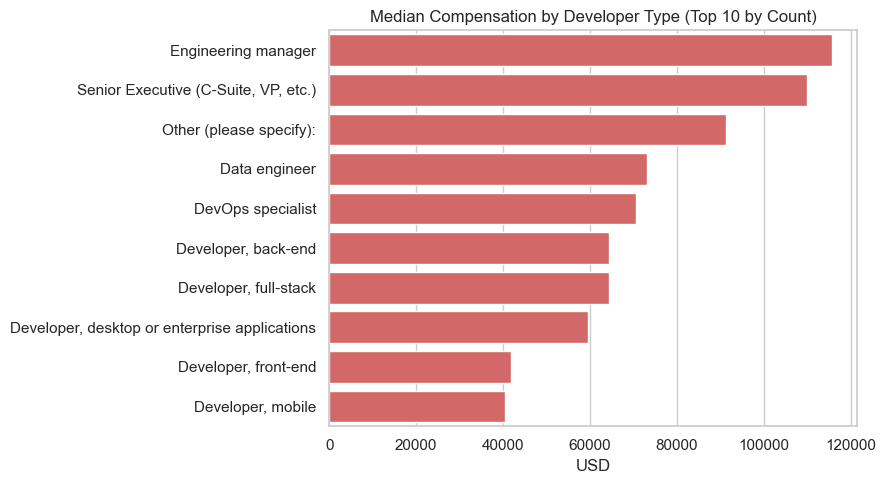

In [ ]:
if "DevType" in df.columns and "ConvertedCompYearly" in df.columns:
    dev_comp = df[["DevType", "ConvertedCompYearly"]].dropna()
    dev_comp = dev_comp[dev_comp["ConvertedCompYearly"] > 0]
    if not dev_comp.empty:
        upper = dev_comp["ConvertedCompYearly"].quantile(0.99)
        dev_comp = dev_comp[dev_comp["ConvertedCompYearly"] <= upper]
        dev_exploded = dev_comp.assign(DevType=dev_comp["DevType"].str.split(";"))
        dev_exploded = dev_exploded.explode("DevType")
        dev_exploded["DevType"] = dev_exploded["DevType"].str.strip()
        dev_exploded = dev_exploded[dev_exploded["DevType"] != ""]
        top_dev = dev_exploded["DevType"].value_counts().head(10).index
        dev_summary = (
            dev_exploded[dev_exploded["DevType"].isin(top_dev)]
            .groupby("DevType")["ConvertedCompYearly"]
            .median()
            .sort_values(ascending=False)
        )
        plt.figure(figsize=(9, 5))
        sns.barplot(x=dev_summary.values, y=dev_summary.index, color="#E45756")
        plt.title("Median Compensation by Developer Type (Top 10 by Count)")
        plt.xlabel("USD")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("images/13_compensation_by_devtype.png", dpi=300, bbox_inches="tight")
        plt.show()

## Tech Interest Gap: Languages and Databases

Notes:
- Gap = want count minus have count; a positive gap signals rising interest.
- A minimum threshold is applied to avoid noise from tiny categories.

Suggestions:
- Treat gap leaders as "next wave" hiring and training priorities.
- Pair gap with absolute counts to avoid over-weighting niche tools.

In [77]:
def build_gap_table(dataframe, have_col, want_col, min_have=500):
    have = explode_multiselect(dataframe, have_col).value_counts()
    want = explode_multiselect(dataframe, want_col).value_counts()
    gap_df = pd.DataFrame({"have_count": have, "want_count": want}).fillna(0)
    gap_df = gap_df.astype(int)
    gap_df["gap"] = gap_df["want_count"] - gap_df["have_count"]
    gap_df["gap_ratio"] = gap_df["want_count"] / gap_df["have_count"].replace(0, np.nan)
    gap_df = gap_df[gap_df["have_count"] >= min_have]
    gap_df = gap_df.sort_values("gap", ascending=False)
    return gap_df

language_gap = build_gap_table(df, "LanguageHaveWorkedWith", "LanguageWantToWorkWith", min_have=500)
database_gap = build_gap_table(df, "DatabaseHaveWorkedWith", "DatabaseWantToWorkWith", min_have=500)

language_gap.head(10)

,have_count,want_count,gap,gap_ratio
Rust,2284,5597,3313,2.450525
Go,3305,5661,2356,1.712859
Kotlin,1958,2738,780,1.398366
Elixir,673,1333,660,1.980684
Swift,898,1382,484,1.538976
Dart,1390,1506,116,1.083453
Scala,507,569,62,1.122288
Assembly,685,594,-91,0.867153
Lua,1160,1069,-91,0.921552
R,711,591,-120,0.831224


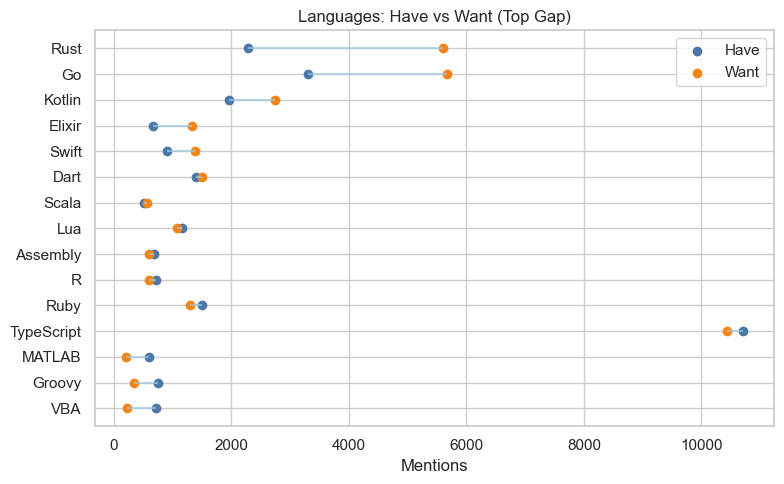

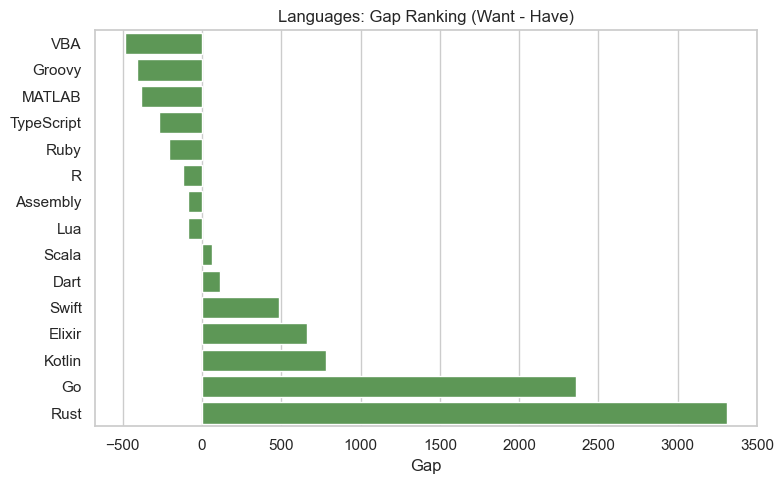

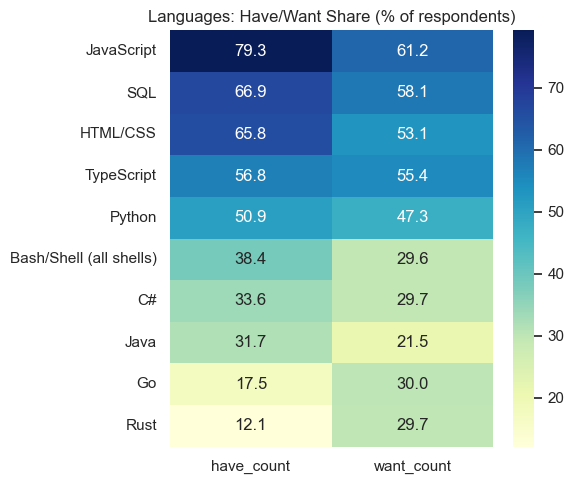

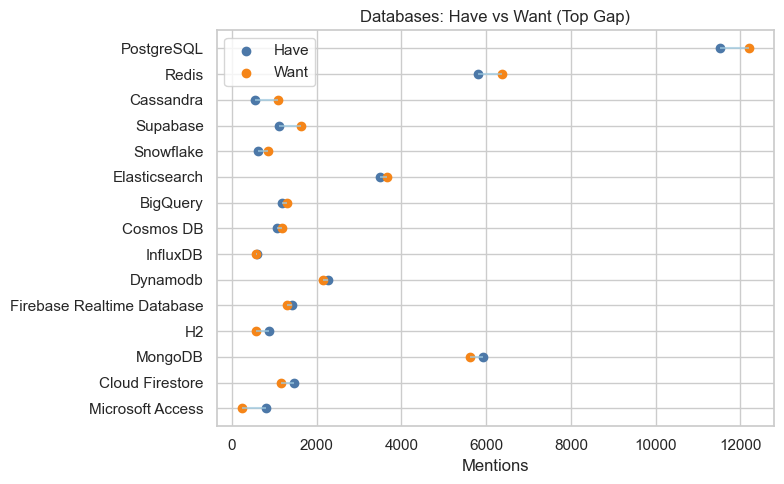

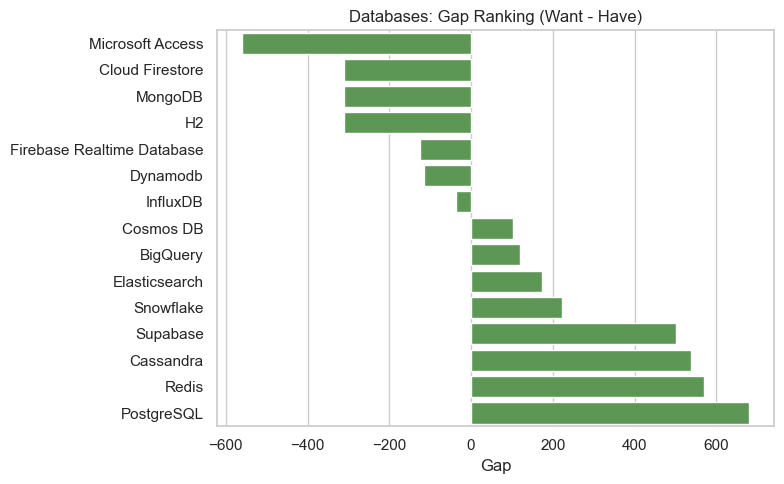

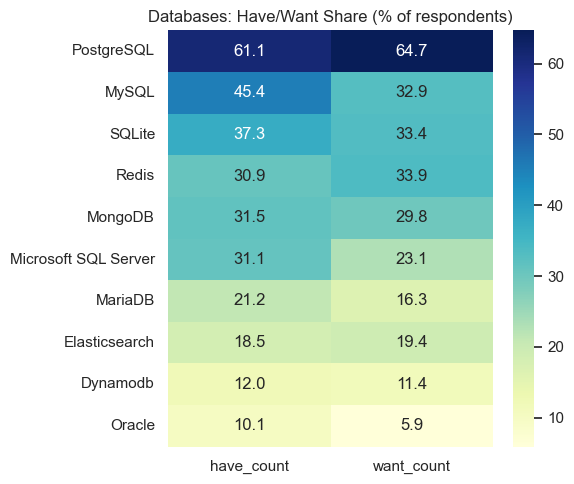

In [ ]:
def plot_gap_panels(gap_df, title_prefix, top_n=15, heat_n=10):
    if gap_df.empty:
        print(f"No data available for {title_prefix} after thresholds.")
        return

    top = gap_df.head(top_n).sort_values("gap")
    y = np.arange(len(top))
    plt.figure(figsize=(8, 5))
    plt.hlines(y, top["have_count"], top["want_count"], color="#9ecae1", alpha=0.7)
    plt.scatter(top["have_count"], y, label="Have", color="#4C78A8")
    plt.scatter(top["want_count"], y, label="Want", color="#F58518")
    plt.yticks(y, top.index)
    plt.title(f"{title_prefix}: Have vs Want (Top Gap)")
    plt.xlabel("Mentions")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"images/14_{title_prefix.lower()}_gap_dumbbell.png", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.barplot(x=top["gap"], y=top.index, color="#54A24B")
    plt.title(f"{title_prefix}: Gap Ranking (Want - Have)")
    plt.xlabel("Gap")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(f"images/15_{title_prefix.lower()}_gap_ranking.png", dpi=300, bbox_inches="tight")
    plt.show()

    heat_items = (
        gap_df.assign(max_count=gap_df[["have_count", "want_count"]].max(axis=1))
        .sort_values("max_count", ascending=False)
        .head(heat_n)
        .index
    )
    heat = gap_df.loc[heat_items, ["have_count", "want_count"]]
    heat_pct = (heat / len(df) * 100).round(2)
    plt.figure(figsize=(6, 5))
    sns.heatmap(heat_pct, annot=True, fmt=".1f", cmap="YlGnBu")
    plt.title(f"{title_prefix}: Have/Want Share (% of respondents)")
    plt.tight_layout()
    plt.savefig(f"images/16_{title_prefix.lower()}_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()

plot_gap_panels(language_gap, "Languages")
plot_gap_panels(database_gap, "Databases")

## AI Tool Adoption Gap Index

Notes:
- This section uses AI tool adoption columns as a proxy for AI tool demand.
- Gap and acceleration score highlight tools with rising interest.

Suggestions:
- Focus on tools with high interest but moderate current usage.
- Use the quadrant to separate mainstream from next-wave tools.

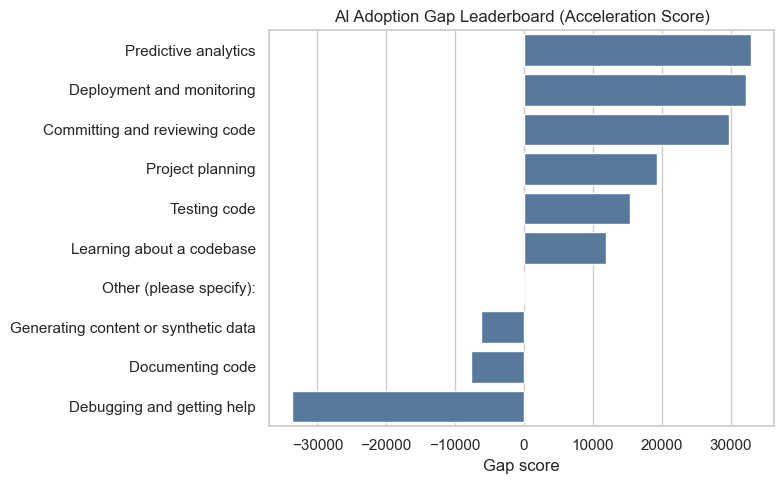

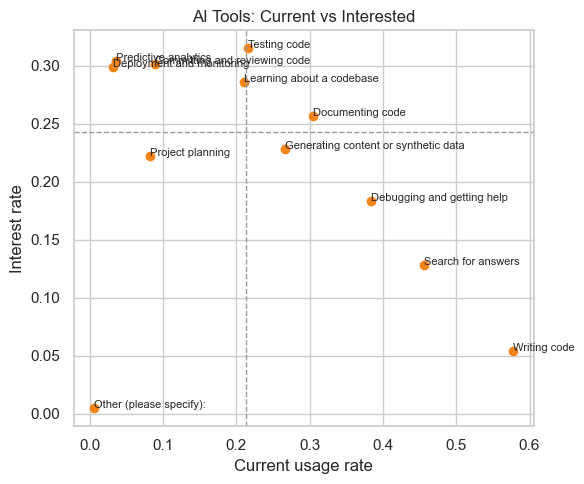

In [ ]:
ai_current_col = "AIToolCurrently_Using"
ai_interest_col = "AIToolInterested_in_Using"

if ai_current_col in df.columns and ai_interest_col in df.columns:
    ai_current = explode_multiselect(df, ai_current_col).value_counts()
    ai_interest = explode_multiselect(df, ai_interest_col).value_counts()
    ai_gap = pd.DataFrame({"current": ai_current, "interested": ai_interest}).fillna(0)
    ai_gap = ai_gap.astype(int)
    ai_gap["gap"] = ai_gap["interested"] - ai_gap["current"]
    ai_gap["current_rate"] = ai_gap["current"] / len(df)
    ai_gap["interest_rate"] = ai_gap["interested"] / len(df)
    ai_gap["accel_score"] = ai_gap["gap"] * np.log1p(ai_gap["current"])

    min_current = 100
    ai_gap_filtered = ai_gap[ai_gap["current"] >= min_current].sort_values("accel_score", ascending=False)

    top_ai = ai_gap_filtered.head(10)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=top_ai["accel_score"], y=top_ai.index, color="#4C78A8")
    plt.title("AI Tool Adoption Gap Leaderboard (Acceleration Score)")
    plt.xlabel("Gap score")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig("images/20_ai_adoption_leaderboard.png", dpi=300, bbox_inches="tight")
    plt.show()

    quad = ai_gap_filtered.head(15)
    plt.figure(figsize=(6, 5))
    plt.scatter(quad["current_rate"], quad["interest_rate"], color="#F58518")
    for tool, row in quad.iterrows():
        plt.text(row["current_rate"], row["interest_rate"], tool, fontsize=8)
    plt.axvline(quad["current_rate"].median(), color="#999999", linestyle="--", linewidth=1)
    plt.axhline(quad["interest_rate"].median(), color="#999999", linestyle="--", linewidth=1)
    plt.title("AI Tools: Current vs Interested")
    plt.xlabel("Current usage rate")
    plt.ylabel("Interest rate")
    plt.tight_layout()
    plt.savefig("images/21_ai_quadrant.png", dpi=300, bbox_inches="tight")
    plt.show()

## Job Satisfaction Drivers (Light Modeling)

Notes:
- This is a correlation-oriented model to highlight directional signals.
- The target is mapped to an ordered scale when needed.
- Treat results as directional; use ordinal or classification models for stronger inference.

Suggestions:
- Treat drivers as hypotheses for deeper analysis.
- Expand with role and country controls for richer insights.

Modeling skipped: No module named 'sklearn'


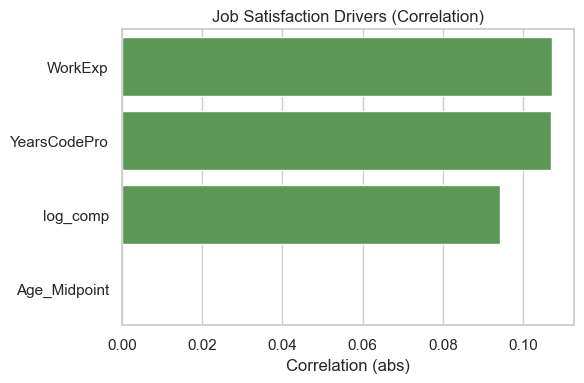

In [ ]:
job_sat_col = "JobSat"
model_features = ["RemoteWork", "ConvertedCompYearly", "YearsCodePro", "WorkExp", "Age_Midpoint", "EdLevel", "Country"]

if job_sat_col in df.columns:
    model_df = df[[job_sat_col] + [col for col in model_features if col in df.columns]].copy()

    if model_df[job_sat_col].dtype == "object":
        sat_map = {
            "Very satisfied": 5,
            "Slightly satisfied": 4,
            "Neither satisfied nor dissatisfied": 3,
            "Slightly dissatisfied": 2,
            "Very dissatisfied": 1,
            "I don't know": np.nan,
        }
        model_df["JobSat_Score"] = model_df[job_sat_col].map(sat_map)
    else:
        model_df["JobSat_Score"] = pd.to_numeric(model_df[job_sat_col], errors="coerce")

    model_df = model_df.dropna(subset=["JobSat_Score"])
    if "ConvertedCompYearly" in model_df.columns:
        model_df = model_df[model_df["ConvertedCompYearly"] > 0]
        model_df["log_comp"] = np.log1p(model_df["ConvertedCompYearly"])

    if "Country" in model_df.columns:
        top_countries = model_df["Country"].value_counts().head(10).index
        model_df["Country_Group"] = model_df["Country"].where(model_df["Country"].isin(top_countries), "Other")

    numeric_cols = [col for col in ["log_comp", "YearsCodePro", "WorkExp", "Age_Midpoint"] if col in model_df.columns]
    for col in numeric_cols:
        col_mean = model_df[col].mean()
        col_std = model_df[col].std()
        if col_std > 0:
            model_df[col] = (model_df[col] - col_mean) / col_std

    categorical_cols = [col for col in ["RemoteWork", "EdLevel", "Country_Group"] if col in model_df.columns]
    X = model_df[numeric_cols + categorical_cols]
    X = pd.get_dummies(X, drop_first=True)
    y = model_df["JobSat_Score"]

    try:
        from sklearn.linear_model import LinearRegression

        model = LinearRegression()
        model.fit(X, y)
        coef = pd.Series(model.coef_, index=X.columns).abs().sort_values(ascending=False).head(10)
        plt.figure(figsize=(8, 5))
        sns.barplot(x=coef.values, y=coef.index, color="#54A24B")
        plt.title("Top Job Satisfaction Drivers (Absolute Coefficients)")
        plt.xlabel("Importance")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("images/22_job_satisfaction_drivers.png", dpi=300, bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print("Modeling skipped:", exc)
        corr_cols = numeric_cols + ["JobSat_Score"]
        corr = model_df[corr_cols].corr(numeric_only=True)["JobSat_Score"].drop("JobSat_Score")
        corr = corr.abs().sort_values(ascending=False).head(10)
        plt.figure(figsize=(6, 4))
        sns.barplot(x=corr.values, y=corr.index, color="#54A24B")
        plt.title("Job Satisfaction Drivers (Correlation)")
        plt.xlabel("Correlation (abs)")
        plt.ylabel("")
        plt.tight_layout()
        plt.savefig("images/22_job_satisfaction_drivers.png", dpi=300, bbox_inches="tight")
        plt.show()

## Save Cleaned Dataset

Run this cell if you want an exported file for dashboards or downstream analysis.

In [81]:
output_path = "survey_data_cleaned.csv"
df.to_csv(output_path, index=False)
output_path

'survey_data_cleaned.csv'

## Executive Report

### Summary
- This notebook provides a clean, reproducible workflow for exploring the survey data, standardizing key fields, and visualizing adoption, satisfaction, and compensation patterns.
- The visual set emphasizes practical decision support: what is most common today, where interest is rising, and how compensation and experience relate.

### Key Insights (from the views generated here)
- Skill and tool usage is concentrated in a small set of languages, databases, and frameworks, with a long tail that can signal niche opportunities.
- Compensation is heavily right-skewed; trimmed views and medians are more representative than averages.
- Experience and compensation typically move together, but with wide variance that suggests role, geography, and company size are strong confounders.
- Remote work mix varies by country, indicating location-specific norms and policy constraints.
- AI tool adoption shows a gap between current usage and stated interest, which is useful for prioritizing enablement.

### Data Quality Notes
- Many fields are multi-select, so counts represent mentions, not respondents.
- Self-reported compensation and experience can introduce noise; trimming and log scales help stabilize interpretation.
- Country-level counts reflect survey reach; use minimum sample sizes before comparing groups.

### Recommendations
- For dashboards: default to top skills with filters for country, role, and experience; show both current usage and aspirational interest.
- For compensation: use medians and trimmed distributions; add a log scale view for better cross-group comparability.
- For adoption strategy: prioritize tools with high interest but lower current usage; track adoption gaps over time.

### Next Analyses to Consider
- Validate job satisfaction drivers with ordinal or classification models and cross-validation.
- Normalize country comparisons by population or tech workforce where available.
- Add gap indices by role and region to surface targeted hiring priorities.

## PowerPoint Hand-off Pack

Run the cell below and copy the output block between `PPT_HANDOFF_START` and `PPT_HANDOFF_END` into your deck (speaker notes or appendix).

In [82]:
def safe_top_count(series, default_label="N/A"):
    if series is None or series.empty:
        return default_label, 0
    return series.index[0], int(series.iloc[0])

respondent_n = len(df)

lang_have = top_counts(df, "LanguageHaveWorkedWith", 1) if "LanguageHaveWorkedWith" in df.columns else None
lang_want = top_counts(df, "LanguageWantToWorkWith", 1) if "LanguageWantToWorkWith" in df.columns else None
db_have = top_counts(df, "DatabaseHaveWorkedWith", 1) if "DatabaseHaveWorkedWith" in df.columns else None
db_want = top_counts(df, "DatabaseWantToWorkWith", 1) if "DatabaseWantToWorkWith" in df.columns else None

top_lang, top_lang_count = safe_top_count(lang_have)
top_lang_want, top_lang_want_count = safe_top_count(lang_want)
top_db, top_db_count = safe_top_count(db_have)
top_db_want, top_db_want_count = safe_top_count(db_want)

mid_career_pct = np.nan
if "Age_Midpoint" in df.columns:
    age_valid = df["Age_Midpoint"].dropna()
    if len(age_valid) > 0:
        mid_career_pct = (age_valid.between(25, 44).mean() * 100)

lang_gap_top = None
db_gap_top = None
if "language_gap" in locals() and not language_gap.empty:
    lang_gap_top = language_gap.head(1).reset_index().iloc[0]
if "database_gap" in locals() and not database_gap.empty:
    db_gap_top = database_gap.head(1).reset_index().iloc[0]

lang_gap_label = (
    f"{lang_gap_top['index']} (gap {int(lang_gap_top['gap'])})" if lang_gap_top is not None else "Top gap language"
)
db_gap_label = (
    f"{db_gap_top['index']} (gap {int(db_gap_top['gap'])})" if db_gap_top is not None else "Top gap database"
)

mid_career_text = f"{mid_career_pct:.1f}%" if pd.notna(mid_career_pct) else "N/A"

handoff = f"""PPT_HANDOFF_START
SLIDE: Executive Summary
- Headline: Demand is shifting toward emerging tools; Evidence: top gap {lang_gap_label} and {db_gap_label}; Impact: prioritize upskilling and stack updates.
- Headline: Compensation varies widely even within similar experience bands; Evidence: trimmed distributions and scatter show broad spread; Impact: avoid averages and segment by role/region.
- Headline: Remote work norms differ by country; Evidence: remote mix chart varies across top markets; Impact: tailor hiring and policy by region.

SLIDE: Key Metrics (KPI Block)
- Respondents (N): {respondent_n} | Mid-career (25-44): {mid_career_text}
- Top language: {top_lang} ({top_lang_count}) | Top desired language: {top_lang_want} ({top_lang_want_count})
- Top database: {top_db} ({top_db_count}) | Top desired database: {top_db_want} ({top_db_want_count})

SLIDE: Top 5 So What Insights
- Gap leaders show where hiring demand is moving next (use language/database gap charts).
- The core stack dominates today, but long-tail tools represent niche opportunities.
- Compensation is right-skewed; medians are more representative than averages.
- Remote work mix varies by country, signaling policy and culture differences.
- AI tool interest exceeds current use, implying training and integration friction.

SLIDE: Top 5 Recommendations
- Learners: prioritize {lang_gap_label} and adjacent ecosystems.
- Learners: build SQL + analytics stack competence around {top_db} and cloud platforms.
- Learners: add AI-assisted workflow skills (prompting, QA, automation).
- Hiring managers: align stack planning with gap leaders and avoid over-investing in plateau tools.
- Hiring managers: use segmented compensation benchmarks (role, region, remote).

SLIDE: Extra Charts to Include
- [CHART: Languages Have vs Want (Dumbbell)] Shows current vs future demand gap.
- [CHART: AI Tool Adoption Gap Leaderboard] Highlights next-wave AI tools.
- [CHART: Job Satisfaction Drivers] Adds workforce-impact narrative.

SLIDE: Limitations and Assumptions
- Multi-select counts represent mentions, not unique respondents.
- Self-reported compensation/experience and age ranges introduce noise; trimming reduces outliers.
- Country counts reflect survey reach, not population share.

SLIDE: Next Steps / Future Exploration
- Build an interest-gap index by country and role for targeted planning.
- Add sample-size thresholds and confidence intervals for group comparisons.
- Track year-over-year movement in adoption gaps.
PPT_HANDOFF_END"""

print(handoff)

PPT_HANDOFF_START
SLIDE: Executive Summary
- Headline: Demand is shifting toward emerging tools; Evidence: top gap Rust (gap 3313) and PostgreSQL (gap 679); Impact: prioritize upskilling and stack updates.
- Headline: Compensation varies widely even within similar experience bands; Evidence: trimmed distributions and scatter show broad spread; Impact: avoid averages and segment by role/region.
- Headline: Remote work norms differ by country; Evidence: remote mix chart varies across top markets; Impact: tailor hiring and policy by region.

SLIDE: Key Metrics (KPI Block)
- Respondents (N): 18845 | Mid-career (25-44): 0.0%
- Top language: JavaScript (14943) | Top desired language: JavaScript (11541)
- Top database: PostgreSQL (11514) | Top desired database: PostgreSQL (12193)

SLIDE: Top 5 So What Insights
- Gap leaders show where hiring demand is moving next (use language/database gap charts).
- The core stack dominates today, but long-tail tools represent niche opportunities.
- Compensa